# 03 — Price Elasticity Modelling

## Retail Pricing and Promotion Optimization

This notebook estimates product-level price elasticity using the synthetic retail dataset.

### Objectives

- Prepare a suitable dataset for elasticity estimation
- Examine within-product price variation
- Estimate a simple log-log demand model
- Estimate an adjusted model with business controls
- Calculate product-level elasticities
- Compare estimated elasticities with known synthetic values
- Simulate price, demand, and revenue scenarios

> The estimates in this notebook are associational. Price may be influenced by expected demand, promotions, seasonality, and other business decisions. A causal IV/2SLS model will be developed in the next notebook.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\marja\OneDrive\Desktop\GitHub\retail-pricing-promotion-optimization


In [2]:
from src.data.io import load_synthetic_retail_data


retail = load_synthetic_retail_data()
retail["date"] = pd.to_datetime(retail["date"])

print(f"Dataset shape: {retail.shape}")
print(
    f"Date range: {retail['date'].min().date()} "
    f"to {retail['date'].max().date()}"
)

retail.head()

Dataset shape: (18300, 29)
Date range: 2024-01-01 to 2024-12-31


,date,store_id,region,product_id,category,year,month,day_of_week,weekend_flag,holiday_flag,regular_price,selling_price,competitor_price,unit_cost,discount_pct,promotion_flag,promotion_type,promotion_propensity,advertising_spend,supplier_cost_index,shipping_cost_index,weather_index,customer_traffic,inventory_level,stockout_flag,units_sold,revenue,gross_profit,true_price_elasticity
0,2024-01-01,S001,West,P001,Beverages,2024,1,Monday,0,1,4.3900,4.3900,4.4800,2.1200,0.0000,0,none,0.2300,15.4700,1.0024,1.0188,0.5661,1206,72,0,54,236.8500,122.6100,-1.8000
1,2024-01-01,S001,West,P002,Beverages,2024,1,Monday,0,1,7.0600,7.0600,7.6000,3.2200,0.0000,0,none,0.2300,21.7400,1.0024,1.0188,0.5661,1206,45,0,44,310.5100,168.6800,-2.1000
2,2024-01-01,S001,West,P003,Beverages,2024,1,Monday,0,1,9.5900,9.5900,9.6400,4.6300,0.0000,0,none,0.2300,12.5500,1.0024,1.0188,0.5661,1206,41,0,40,383.7000,198.3500,-2.4000
3,2024-01-01,S001,West,P004,Grocery,2024,1,Monday,0,1,4.0100,3.6100,3.8600,1.7600,0.1000,1,feature_display,0.2000,55.8300,1.0024,1.0188,0.5661,1206,117,0,115,414.8800,212.1600,-1.4000
4,2024-01-01,S001,West,P005,Grocery,2024,1,Monday,0,1,5.4800,5.4800,5.3200,2.5700,0.0000,0,none,0.2000,23.2000,1.0024,1.0188,0.5661,1206,80,0,58,318.0700,169.0800,-1.7000


In [3]:
elasticity_data = retail.loc[
    (retail["units_sold"] > 0)
    & (retail["selling_price"] > 0)
    & (retail["competitor_price"] > 0)
    & (retail["stockout_flag"] == 0)
].copy()

elasticity_data["log_units_sold"] = np.log(
    elasticity_data["units_sold"]
)

elasticity_data["log_selling_price"] = np.log(
    elasticity_data["selling_price"]
)

elasticity_data["log_competitor_price"] = np.log(
    elasticity_data["competitor_price"]
)

elasticity_data["log_customer_traffic"] = np.log(
    elasticity_data["customer_traffic"]
)

elasticity_data["log_advertising_spend"] = np.log1p(
    elasticity_data["advertising_spend"]
)

sample_summary = pd.Series(
    {
        "Original observations": len(retail),
        "Elasticity observations": len(elasticity_data),
        "Excluded observations": (
            len(retail) - len(elasticity_data)
        ),
        "Products": elasticity_data["product_id"].nunique(),
        "Stores": elasticity_data["store_id"].nunique(),
        "Minimum selling price": (
            elasticity_data["selling_price"].min()
        ),
        "Maximum selling price": (
            elasticity_data["selling_price"].max()
        ),
    },
    name="Value",
)

sample_summary.to_frame()

,Value
Original observations,"18,300.0000"
Elasticity observations,"14,209.0000"
Excluded observations,"4,091.0000"
Products,10.0000
Stores,5.0000
Minimum selling price,2.8900
Maximum selling price,13.5900


In [4]:
price_variation = (
    elasticity_data.groupby(
        ["product_id", "category"],
        as_index=False,
    )
    .agg(
        observations=("units_sold", "size"),
        minimum_price=("selling_price", "min"),
        average_price=("selling_price", "mean"),
        maximum_price=("selling_price", "max"),
        price_standard_deviation=(
            "selling_price",
            "std",
        ),
        average_units_sold=("units_sold", "mean"),
        true_elasticity=(
            "true_price_elasticity",
            "first",
        ),
    )
)

price_variation["price_range_pct"] = (
    (
        price_variation["maximum_price"]
        - price_variation["minimum_price"]
    )
    / price_variation["average_price"]
    * 100
)

price_variation

,product_id,category,observations,minimum_price,average_price,maximum_price,price_standard_deviation,average_units_sold,true_elasticity,price_range_pct
0,P001,Beverages,1413,3.2300,4.3753,4.6900,0.2801,49.0686,-1.8000,33.3694
1,P002,Beverages,1440,5.0700,6.7992,7.3100,0.4503,40.0069,-2.1000,32.9451
2,P003,Beverages,1419,6.8100,9.2501,9.9100,0.5833,28.7456,-2.4000,33.5131
3,P004,Grocery,1445,2.8900,3.9029,4.1700,0.2367,56.4152,-1.4000,32.7959
4,P005,Grocery,1439,3.9800,5.3686,5.7400,0.3255,45.6970,-1.7000,32.7834
5,P006,Grocery,1426,6.4700,8.7941,9.4200,0.4991,31.8892,-2.0000,33.5450
6,P007,Household,1393,5.4700,7.3450,7.8100,0.4081,24.0179,-1.2000,31.8584
7,P008,Household,1405,9.4200,12.7122,13.5900,0.7582,18.4135,-1.5000,32.8030
8,P009,Personal Care,1434,4.7500,6.3412,6.8000,0.3870,29.5258,-1.3000,32.3285
9,P010,Personal Care,1395,7.9500,10.7435,11.5200,0.6562,20.9649,-1.6000,33.2293


In [5]:
simple_model = smf.ols(
    formula=(
        "log_units_sold ~ log_selling_price"
    ),
    data=elasticity_data,
).fit(cov_type="HC3")

simple_elasticity = simple_model.params[
    "log_selling_price"
]

simple_ci = simple_model.conf_int().loc[
    "log_selling_price"
]

simple_result = pd.Series(
    {
        "Estimated elasticity": simple_elasticity,
        "Robust standard error": simple_model.bse[
            "log_selling_price"
        ],
        "Lower 95% confidence limit": simple_ci.iloc[0],
        "Upper 95% confidence limit": simple_ci.iloc[1],
        "P-value": simple_model.pvalues[
            "log_selling_price"
        ],
        "R-squared": simple_model.rsquared,
        "Observations": int(simple_model.nobs),
    },
    name="Simple model",
)

simple_result.to_frame()

,Simple model
Estimated elasticity,-0.9920
Robust standard error,0.0074
Lower 95% confidence limit,-1.0065
Upper 95% confidence limit,-0.9775
P-value,0.0000
R-squared,0.5237
Observations,"14,209.0000"


In [6]:
adjusted_formula = """
log_units_sold
~ log_selling_price
+ log_competitor_price
+ promotion_flag
+ log_customer_traffic
+ log_advertising_spend
+ weekend_flag
+ holiday_flag
+ weather_index
+ C(product_id)
+ C(store_id)
+ C(month)
"""

adjusted_model = smf.ols(
    formula=adjusted_formula,
    data=elasticity_data,
).fit(cov_type="HC3")

In [7]:
def coefficient_summary(
    model,
    variables: list[str],
) -> pd.DataFrame:
    """Return selected model coefficients."""

    confidence_intervals = model.conf_int()

    rows = []

    for variable in variables:
        rows.append(
            {
                "variable": variable,
                "coefficient": model.params[variable],
                "robust_standard_error": model.bse[
                    variable
                ],
                "p_value": model.pvalues[variable],
                "confidence_lower": (
                    confidence_intervals.loc[
                        variable, 0
                    ]
                ),
                "confidence_upper": (
                    confidence_intervals.loc[
                        variable, 1
                    ]
                ),
            }
        )

    return pd.DataFrame(rows)


selected_coefficients = coefficient_summary(
    adjusted_model,
    [
        "log_selling_price",
        "log_competitor_price",
        "promotion_flag",
        "log_customer_traffic",
        "log_advertising_spend",
        "weekend_flag",
        "holiday_flag",
        "weather_index",
    ],
)

selected_coefficients

,variable,coefficient,robust_standard_error,p_value,confidence_lower,confidence_upper
0,log_selling_price,-1.8310,0.0417,0.0000,-1.9128,-1.7492
1,log_competitor_price,0.3298,0.0262,0.0000,0.2784,0.3813
2,promotion_flag,0.2949,0.0082,0.0000,0.2789,0.3109
3,log_customer_traffic,0.4904,0.0185,0.0000,0.4542,0.5266
4,log_advertising_spend,0.0369,0.0029,0.0000,0.0313,0.0425
5,weekend_flag,0.1188,0.0038,0.0000,0.1112,0.1263
6,holiday_flag,0.2008,0.0092,0.0000,0.1828,0.2188
7,weather_index,0.0648,0.0168,0.0001,0.0318,0.0977


In [8]:
model_comparison = pd.DataFrame(
    {
        "model": [
            "Simple log-log model",
            "Adjusted fixed-effects model",
        ],
        "price_elasticity": [
            simple_model.params[
                "log_selling_price"
            ],
            adjusted_model.params[
                "log_selling_price"
            ],
        ],
        "robust_standard_error": [
            simple_model.bse[
                "log_selling_price"
            ],
            adjusted_model.bse[
                "log_selling_price"
            ],
        ],
        "p_value": [
            simple_model.pvalues[
                "log_selling_price"
            ],
            adjusted_model.pvalues[
                "log_selling_price"
            ],
        ],
        "r_squared": [
            simple_model.rsquared,
            adjusted_model.rsquared,
        ],
        "observations": [
            int(simple_model.nobs),
            int(adjusted_model.nobs),
        ],
    }
)

model_comparison

,model,price_elasticity,robust_standard_error,p_value,r_squared,observations
0,Simple log-log model,-0.9920,0.0074,0.0000,0.5237,14209
1,Adjusted fixed-effects model,-1.8310,0.0417,0.0000,0.8732,14209


In [9]:
product_formula = """
log_units_sold
~ log_selling_price
+ log_competitor_price
+ promotion_flag
+ log_customer_traffic
+ log_advertising_spend
+ weekend_flag
+ holiday_flag
+ weather_index
+ C(store_id)
+ C(month)
"""

product_results = []

for product_id, product_data in elasticity_data.groupby(
    "product_id"
):
    product_model = smf.ols(
        formula=product_formula,
        data=product_data,
    ).fit(cov_type="HC3")

    confidence_interval = (
        product_model.conf_int()
        .loc["log_selling_price"]
    )

    product_results.append(
        {
            "product_id": product_id,
            "observations": int(product_model.nobs),
            "estimated_elasticity": (
                product_model.params[
                    "log_selling_price"
                ]
            ),
            "standard_error": (
                product_model.bse[
                    "log_selling_price"
                ]
            ),
            "p_value": (
                product_model.pvalues[
                    "log_selling_price"
                ]
            ),
            "confidence_lower": (
                confidence_interval.iloc[0]
            ),
            "confidence_upper": (
                confidence_interval.iloc[1]
            ),
            "r_squared": product_model.rsquared,
        }
    )

product_elasticity = pd.DataFrame(product_results)

In [10]:
true_elasticity = (
    retail.groupby("product_id", as_index=False)
    .agg(
        category=("category", "first"),
        true_elasticity=(
            "true_price_elasticity",
            "first",
        ),
    )
)

product_elasticity = product_elasticity.merge(
    true_elasticity,
    on="product_id",
    how="left",
)

product_elasticity["estimation_error"] = (
    product_elasticity["estimated_elasticity"]
    - product_elasticity["true_elasticity"]
)

product_elasticity["absolute_error"] = (
    product_elasticity["estimation_error"].abs()
)

product_elasticity = product_elasticity.sort_values(
    "estimated_elasticity"
)

product_elasticity

,product_id,observations,estimated_elasticity,standard_error,p_value,confidence_lower,confidence_upper,r_squared,category,true_elasticity,estimation_error,absolute_error
2,P003,1419,-2.5276,0.1161,0.0000,-2.7552,-2.3000,0.7772,Beverages,-2.4000,-0.1276,0.1276
1,P002,1440,-2.2733,0.0904,0.0000,-2.4504,-2.0961,0.8258,Beverages,-2.1000,-0.1733,0.1733
5,P006,1426,-2.1148,0.1248,0.0000,-2.3594,-1.8701,0.7569,Grocery,-2.0000,-0.1148,0.1148
0,P001,1413,-1.9357,0.0943,0.0000,-2.1205,-1.7509,0.8280,Beverages,-1.8000,-0.1357,0.1357
4,P005,1439,-1.7968,0.0990,0.0000,-1.9908,-1.6028,0.7993,Grocery,-1.7000,-0.0968,0.0968
7,P008,1405,-1.6716,0.1548,0.0000,-1.9750,-1.3683,0.6499,Household,-1.5000,-0.1716,0.1716
8,P009,1434,-1.4545,0.1330,0.0000,-1.7151,-1.1938,0.7353,Personal Care,-1.3000,-0.1545,0.1545
9,P010,1395,-1.4487,0.1660,0.0000,-1.7741,-1.1234,0.6629,Personal Care,-1.6000,0.1513,0.1513
3,P004,1445,-1.3624,0.0981,0.0000,-1.5547,-1.1701,0.8251,Grocery,-1.4000,0.0376,0.0376
6,P007,1393,-1.3465,0.1524,0.0000,-1.6452,-1.0478,0.6710,Household,-1.2000,-0.1465,0.1465


In [11]:
elasticity_evaluation = pd.Series(
    {
        "Mean estimated elasticity": (
            product_elasticity[
                "estimated_elasticity"
            ].mean()
        ),
        "Mean true elasticity": (
            product_elasticity[
                "true_elasticity"
            ].mean()
        ),
        "Mean absolute error": (
            product_elasticity[
                "absolute_error"
            ].mean()
        ),
        "Correlation with true elasticity": (
            product_elasticity[
                [
                    "estimated_elasticity",
                    "true_elasticity",
                ]
            ]
            .corr()
            .iloc[0, 1]
        ),
        "Statistically significant products": (
            product_elasticity["p_value"]
            .lt(0.05)
            .sum()
        ),
    },
    name="Value",
)

elasticity_evaluation.to_frame()

,Value
Mean estimated elasticity,-1.7932
Mean true elasticity,-1.7000
Mean absolute error,0.1310
Correlation with true elasticity,0.9679
Statistically significant products,10.0000


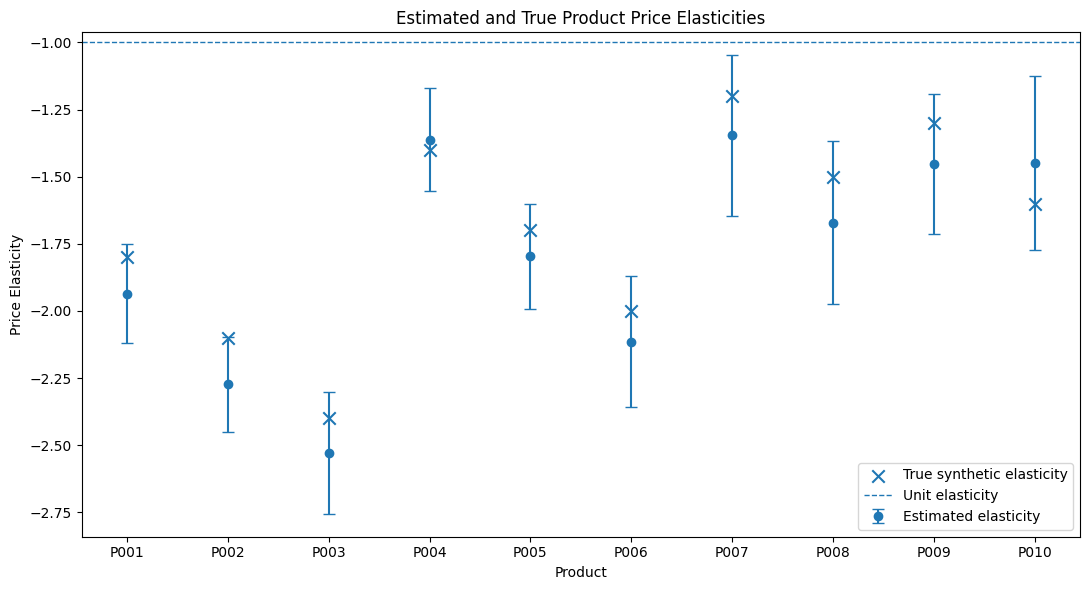

In [12]:
plot_data = product_elasticity.sort_values(
    "product_id"
)

x_positions = np.arange(len(plot_data))

plt.figure(figsize=(11, 6))

plt.errorbar(
    x_positions,
    plot_data["estimated_elasticity"],
    yerr=1.96 * plot_data["standard_error"],
    fmt="o",
    capsize=4,
    label="Estimated elasticity",
)

plt.scatter(
    x_positions,
    plot_data["true_elasticity"],
    marker="x",
    s=80,
    label="True synthetic elasticity",
)

plt.axhline(
    y=-1,
    linestyle="--",
    linewidth=1,
    label="Unit elasticity",
)

plt.xticks(
    x_positions,
    plot_data["product_id"],
)

plt.title("Estimated and True Product Price Elasticities")
plt.xlabel("Product")
plt.ylabel("Price Elasticity")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "estimated_vs_true_elasticity.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [13]:
def classify_elasticity(value: float) -> str:
    """Classify demand using the elasticity magnitude."""

    if value < -1:
        return "Elastic"

    if value > -1:
        return "Inelastic"

    return "Unit elastic"


product_elasticity["elasticity_class"] = (
    product_elasticity["estimated_elasticity"]
    .apply(classify_elasticity)
)

product_elasticity[
    [
        "product_id",
        "category",
        "estimated_elasticity",
        "true_elasticity",
        "elasticity_class",
        "p_value",
    ]
]

,product_id,category,estimated_elasticity,true_elasticity,elasticity_class,p_value
2,P003,Beverages,-2.5276,-2.4000,Elastic,0.0000
1,P002,Beverages,-2.2733,-2.1000,Elastic,0.0000
5,P006,Grocery,-2.1148,-2.0000,Elastic,0.0000
0,P001,Beverages,-1.9357,-1.8000,Elastic,0.0000
4,P005,Grocery,-1.7968,-1.7000,Elastic,0.0000
7,P008,Household,-1.6716,-1.5000,Elastic,0.0000
8,P009,Personal Care,-1.4545,-1.3000,Elastic,0.0000
9,P010,Personal Care,-1.4487,-1.6000,Elastic,0.0000
3,P004,Grocery,-1.3624,-1.4000,Elastic,0.0000
6,P007,Household,-1.3465,-1.2000,Elastic,0.0000


In [14]:
selected_product = (
    product_elasticity.iloc[0]["product_id"]
)

selected_elasticity = (
    product_elasticity.loc[
        product_elasticity["product_id"]
        == selected_product,
        "estimated_elasticity",
    ].iloc[0]
)

selected_history = elasticity_data.loc[
    elasticity_data["product_id"]
    == selected_product
]

baseline_price = selected_history[
    "selling_price"
].mean()

baseline_units = selected_history[
    "units_sold"
].mean()

scenario_prices = np.linspace(
    baseline_price * 0.80,
    baseline_price * 1.20,
    41,
)

scenario_units = baseline_units * (
    scenario_prices / baseline_price
) ** selected_elasticity

scenario_revenue = (
    scenario_prices * scenario_units
)

price_scenarios = pd.DataFrame(
    {
        "selling_price": scenario_prices,
        "expected_units": scenario_units,
        "expected_revenue": scenario_revenue,
    }
)

print(f"Selected product: {selected_product}")
print(
    f"Estimated elasticity: "
    f"{selected_elasticity:.3f}"
)

price_scenarios.head()

Selected product: P003
Estimated elasticity: -2.528


,selling_price,expected_units,expected_revenue
0,7.4001,50.5269,373.9038
1,7.4926,48.9651,366.8752
2,7.5851,47.4698,360.0625
3,7.6776,46.0374,353.4566
4,7.7701,44.6647,347.0489


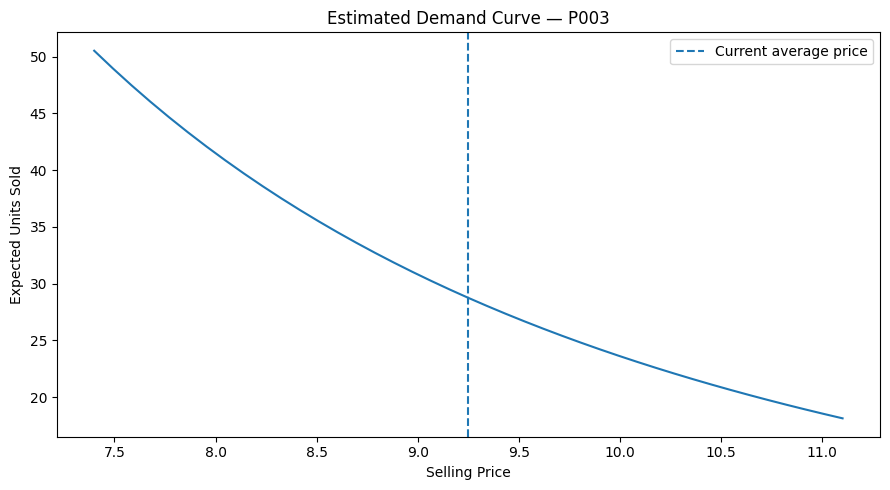

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    price_scenarios["selling_price"],
    price_scenarios["expected_units"],
)

plt.axvline(
    baseline_price,
    linestyle="--",
    label="Current average price",
)

plt.title(
    f"Estimated Demand Curve — {selected_product}"
)
plt.xlabel("Selling Price")
plt.ylabel("Expected Units Sold")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "price_demand_scenario.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

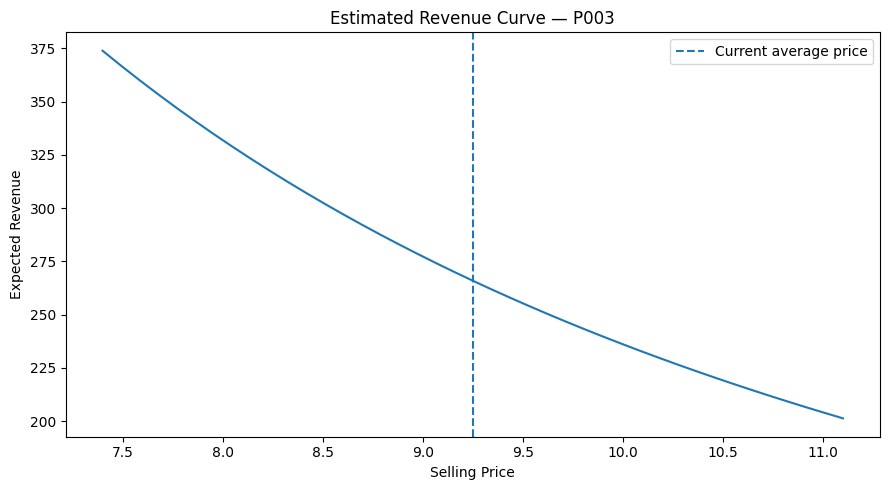

In [16]:
plt.figure(figsize=(9, 5))

plt.plot(
    price_scenarios["selling_price"],
    price_scenarios["expected_revenue"],
)

plt.axvline(
    baseline_price,
    linestyle="--",
    label="Current average price",
)

plt.title(
    f"Estimated Revenue Curve — {selected_product}"
)
plt.xlabel("Selling Price")
plt.ylabel("Expected Revenue")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "price_revenue_scenario.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [17]:
elasticity_output_path = (
    PROCESSED_DATA_DIR
    / "product_elasticity_estimates.csv"
)

product_elasticity.to_csv(
    elasticity_output_path,
    index=False,
)

print(
    f"Elasticity estimates saved to: "
    f"{elasticity_output_path}"
)

Elasticity estimates saved to: c:\Users\marja\OneDrive\Desktop\GitHub\retail-pricing-promotion-optimization\data\processed\product_elasticity_estimates.csv


## Key Findings

- The simple model estimates the unconditional relationship between price and demand.
- The adjusted model controls for competitor prices, promotions, advertising, customer traffic, calendar effects, stores, and products.
- Product-level elasticity differs because products have different levels of price sensitivity.
- Products with elasticity below `-1` are classified as price elastic.
- Products with elasticity between `-1` and `0` are classified as price inelastic.
- Stockout observations were excluded because observed sales may be constrained by inventory availability.
- The synthetic true-elasticity values provide a benchmark for evaluating estimation accuracy.
- Price scenarios illustrate how estimated elasticity can support revenue analysis.
- These results should not yet be interpreted as causal because price-setting decisions may be endogenous.
- The next notebook will use instrumental variables and 2SLS to estimate a more defensible causal price effect.